## Linear Regression with ML

### Single Test

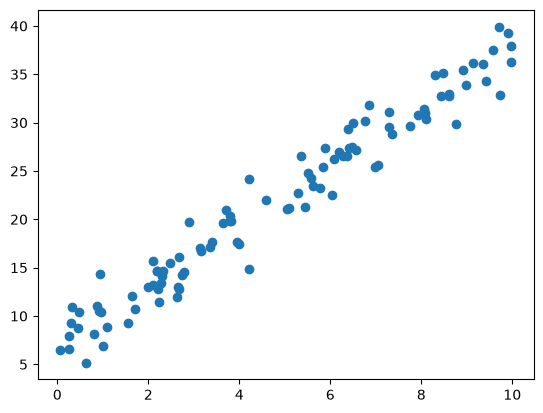

In [4]:
import random
import math

random.seed(42)

TRUE_W = 3.0
TRUE_B = 7.0
N_SAMPLES = 100

X = [random.uniform(0, 10) for _ in range(N_SAMPLES)]
y = [TRUE_W * x + TRUE_B + random.gauss(0, 2.0) for x in X]

%matplotlib inline
import matplotlib.pyplot as plt

plt.scatter(X, y)
plt.show()


Epoch 0/1000, Cost: 263.0919, W: 1.3073, b: 0.2174
Epoch 200/1000, Cost: 7.4251, W: 3.6454, b: 3.2610
Epoch 400/1000, Cost: 4.9453, W: 3.4099, b: 4.8006
Epoch 600/1000, Cost: 4.0920, W: 3.2717, b: 5.7038
Epoch 800/1000, Cost: 3.7984, W: 3.1906, b: 6.2336

 Learned: y = 3.1433x + 6.5432

 True: y = 3.0000x + 7.0000
R-squared: 0.9566


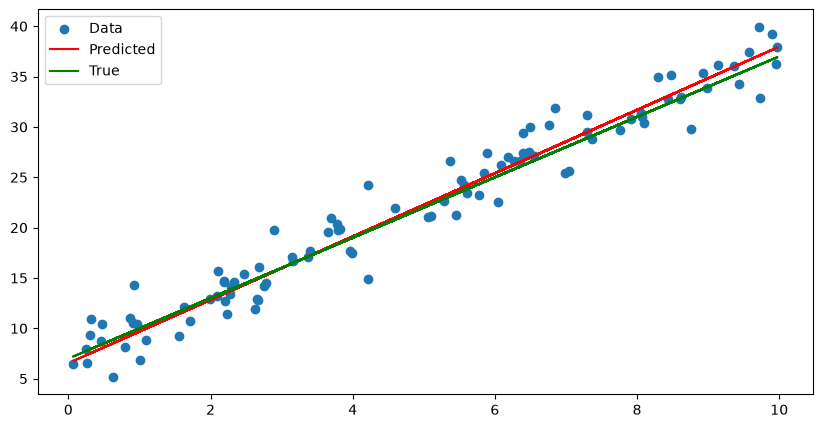

In [5]:
class LinearRegression:
    def __init__(self, lr = 0.01):
        self.w = 0.0
        self.b = 0.0
        self.lr = lr
        self.cost_history = []

    def predict(self, X):
        return [self.w * x + self.b for x in X]

    def compute_cost(self, X, y):
        predictions = self.predict(X)
        n = len(y)
        cost = sum(
            (prediction - actual) ** 2 for prediction, actual in zip(predictions, y)
        ) / n
        return cost

    def compute_gradients(self, X, y):
        predictions = self.predict(X)
        n = len(y)

        dw = (2 / n) * sum(
            (pred - actual) * x for pred, actual, x in zip(predictions, y, X)
        )
        db = (2 / n) * sum(
            pred - actual for pred, actual in zip(predictions, y)
        )
        return dw, db
    
    def fit(self, X, y, epochs = 1000, print_every = 200):
        for epoch in range(epochs):
            dw, db = self.compute_gradients(X, y)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            cost = self.compute_cost(X, y)

            self.cost_history.append(cost)

            if epoch % print_every == 0:
                print(f"Epoch {epoch}/{epochs}, Cost: {cost:.4f}, W: {self.w:.4f}, b: {self.b:.4f}")

        return self
    
    def r_squared(self, X, y):
        predictions = self.predict(X)
        y_mean = sum(y) / len(y)

        ss_res = sum(
            (actual - pred) ** 2 for actual, pred in zip(y, predictions)
        )
        ss_total = sum(
            (actual - y_mean) ** 2 for actual in y
        )

        return 1 - (ss_res / ss_total)

print("="*60)
model = LinearRegression(lr = 0.005)
model.fit(X, y, epochs=1000, print_every=200)

print(f"\n Learned: y = {model.w:.4f}x + {model.b:.4f}")
print(f"\n True: y = {TRUE_W:.4f}x + {TRUE_B:.4f}")
print(f"R-squared: {model.r_squared(X, y):.4f}")

plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Data")
plt.plot(X, model.predict(X), label="Predicted", color="red")
plt.plot(X, [TRUE_W * x + TRUE_B for x in X], label="True", color="green")
plt.legend()
plt.show()


### Multivariate Test

In [9]:
class MultipleLinearRegression:
    def __init__(self, n_features, learning_rate=0.01):
        self.weights = [0.0] * n_features
        self.bias = 0.0
        self.lr = learning_rate
        self.cost_history = []

    def predict_single(self, x):
        return sum(w * xi for w, xi in zip(self.weights, x)) + self.bias

    def predict(self, X):
        return [self.predict_single(x) for x in X]

    def compute_cost(self, X, y):
        predictions = self.predict(X)
        n = len(y)
        return sum((pred - actual) ** 2 for pred, actual in zip(predictions, y)) / n

    def fit(self, X, y, epochs=1000, print_every=200):
        n = len(y)
        n_features = len(X[0])
        for epoch in range(epochs):
            predictions = self.predict(X)
            errors = [pred - actual for pred, actual in zip(predictions, y)]
            for j in range(n_features):
                grad = (2 / n) * sum(errors[i] * X[i][j] for i in range(n))
                self.weights[j] -= self.lr * grad
            grad_b = (2 / n) * sum(errors)
            self.bias -= self.lr * grad_b
            cost = self.compute_cost(X, y)
            self.cost_history.append(cost)
            if epoch % print_every == 0:
                print(f"  Epoch {epoch:4d} | Cost: {cost:.4f}")
        return self

    def r_squared(self, X, y):
        predictions = self.predict(X)
        y_mean = sum(y) / len(y)
        ss_res = sum((actual - pred) ** 2 for actual, pred in zip(y, predictions))
        ss_tot = sum((actual - y_mean) ** 2 for actual in y)
        return 1 - (ss_res / ss_tot)


random.seed(42)
N = 100
X_multi = []
y_multi = []
for _ in range(N):
    size = random.uniform(500, 3000)
    bedrooms = random.randint(1, 5)
    age = random.uniform(0, 50)
    price = 50 * size + 10000 * bedrooms - 1000 * age + 50000 + random.gauss(0, 20000)
    X_multi.append([size, bedrooms, age])
    y_multi.append(price)


# ------------------------------------------------------------
# 为什么 fit 前要先 standardize？
#
# 本例三个特征量纲差很大：
#   size ~ 500–3000，bedrooms ~ 1–5，age ~ 0–50
# 梯度中含有项 error * X[j]，量纲大的特征会产生更大的梯度。
# 若共用同一个 learning_rate：
#   - lr 偏大 → size 对应权重震荡甚至发散
#   - lr 偏小 → bedrooms / age 收敛极慢
# 标准化后各特征均值≈0、标准差≈1，梯度量级接近，
# 同一个 lr 就能稳定、较快地收敛。
# 对 y 做同样处理，也能让 cost / 权重数值更易观察。
# （闭式解/正规方程不依赖 GD，一般可不强制标准化）
# ------------------------------------------------------------
def standardize(X):
    """将每个特征变为近似 (x - mean) / std，消除量纲差异。"""
    n_features = len(X[0])
    means = [sum(X[i][j] for i in range(len(X))) / len(X) for j in range(n_features)]
    stds = []
    for j in range(n_features):
        variance = sum((X[i][j] - means[j]) ** 2 for i in range(len(X))) / len(X)
        stds.append(variance ** 0.5)
    X_scaled = []
    for i in range(len(X)):
        # std=0 时特征恒定，无法缩放，置 0 即可
        row = [(X[i][j] - means[j]) / stds[j] if stds[j] > 0 else 0 for j in range(n_features)]
        X_scaled.append(row)
    return X_scaled, means, stds


# 对 y 标准化：与 X 同尺度，便于用同一 lr 做梯度下降
y_mean_val = sum(y_multi) / len(y_multi)
y_std_val = (sum((yi - y_mean_val) ** 2 for yi in y_multi) / len(y_multi)) ** 0.5
y_scaled = [(yi - y_mean_val) / y_std_val for yi in y_multi]
print(f"Original Y: {y_multi[:5]}")
print(f"Scaled Y: {y_scaled[:5]}")

X_scaled, x_means, x_stds = standardize(X_multi)

print("\n=== Multiple Linear Regression (3 features) ===")
print("Features: house size, bedrooms, age")
# 必须用标准化后的 X_scaled / y_scaled，而不是原始 X_multi / y_multi
multi_model = MultipleLinearRegression(n_features=3, learning_rate=0.01)
multi_model.fit(X_scaled, y_scaled, epochs=1000, print_every=200)

print(f"\nWeights (standardized): {[round(w, 4) for w in multi_model.weights]}")
print(f"Bias (standardized): {multi_model.bias:.4f}")
print(f"R-squared: {multi_model.r_squared(X_scaled, y_scaled):.4f}")

Original Y: [128202.68693091531, 144424.1883167672, 136007.385118299, 201167.90661250666, 156859.5437067609]
Scaled Y: [-0.24938028065708984, 0.05686417852286182, -0.10203599244325606, 1.1281244094959688, 0.2916302828145777]

=== Multiple Linear Regression (3 features) ===
Features: house size, bedrooms, age
  Epoch    0 | Cost: 0.9582
  Epoch  200 | Cost: 0.1195
  Epoch  400 | Cost: 0.1193
  Epoch  600 | Cost: 0.1193
  Epoch  800 | Cost: 0.1193

Weights (standardized): [0.7716, 0.2773, -0.2739]
Bias (standardized): 0.0000
R-squared: 0.8807


### Deploy: scale → predict → inverse scale

训练时保存的 `x_means` / `x_stds` / `y_mean_val` / `y_std_val` 是部署契约的一部分。
线上对新样本用同一套统计量标准化，预测后再把 `y` 还原到原始量纲。

In [ ]:
def scale_x(x_raw, x_means, x_stds):
    """用训练集统计量把单条原始特征变成标准化特征。"""
    return [
        (x_raw[j] - x_means[j]) / x_stds[j] if x_stds[j] > 0 else 0.0
        for j in range(len(x_raw))
    ]


def inverse_scale_y(y_scaled, y_mean, y_std):
    """把标准化空间的预测值还原到原始 y 量纲。"""
    return y_scaled * y_std + y_mean


def predict_original(model, x_raw, x_means, x_stds, y_mean, y_std):
    """部署路径：原始 X → 标准化 → 模型预测 → 反标准化 y。"""
    x_scaled = scale_x(x_raw, x_means, x_stds)
    y_scaled_pred = model.predict_single(x_scaled)
    return inverse_scale_y(y_scaled_pred, y_mean, y_std)


def true_price(size, bedrooms, age):
    """数据生成时的无噪声真值，便于对照（不含 random.gauss）。"""
    return 50 * size + 10000 * bedrooms - 1000 * age + 50000


print("=== Deploy tests: scale → predict → inverse ===\n")

# --- Test 1: 训练集上前几条样本，预测应接近真实房价 ---
print("Test 1: training samples (pred vs actual)")
mae = 0.0
n_check = 5
for i in range(n_check):
    pred = predict_original(
        multi_model, X_multi[i], x_means, x_stds, y_mean_val, y_std_val
    )
    actual = y_multi[i]
    err = abs(pred - actual)
    mae += err
    print(
        f"  sample {i}: X={ [round(v, 1) for v in X_multi[i]] }"
        f"  pred={pred:,.0f}  actual={actual:,.0f}  |err|={err:,.0f}"
    )
mae /= n_check
print(f"  MAE (first {n_check}): {mae:,.0f}")
assert mae < 30000, f"MAE too large on training samples: {mae}"
print("  PASS\n")

# --- Test 2: 与「先整体标准化再 predict，再 inverse」结果一致 ---
print("Test 2: consistency with batch scaled predict")
for i in [0, 10, 50, 99]:
    via_deploy = predict_original(
        multi_model, X_multi[i], x_means, x_stds, y_mean_val, y_std_val
    )
    via_batch = inverse_scale_y(
        multi_model.predict_single(X_scaled[i]), y_mean_val, y_std_val
    )
    diff = abs(via_deploy - via_batch)
    print(f"  sample {i}: deploy={via_deploy:,.4f}  batch={via_batch:,.4f}  diff={diff:.6f}")
    assert diff < 1e-6, f"deploy path mismatch at sample {i}: {diff}"
print("  PASS\n")

# --- Test 3: 全新原始输入（模拟线上请求）---
print("Test 3: new raw inputs (online-style)")
new_houses = [
    [2000, 3, 10],
    [800, 1, 40],
    [2800, 5, 2],
]
for x_raw in new_houses:
    pred = predict_original(
        multi_model, x_raw, x_means, x_stds, y_mean_val, y_std_val
    )
    noise_free = true_price(*x_raw)
    print(
        f"  X={x_raw}  pred={pred:,.0f}  true(no noise)={noise_free:,.0f}"
        f"  |err|={abs(pred - noise_free):,.0f}"
    )
    # 训练噪声 std=20000，允许一定偏差
    assert abs(pred - noise_free) < 50000, f"pred too far from true formula for {x_raw}"
print("  PASS\n")

# --- Test 4: 反标准化可逆性 ---
print("Test 4: y scale ↔ inverse roundtrip")
for yi in [y_multi[0], y_multi[42], 123456.0]:
    scaled = (yi - y_mean_val) / y_std_val
    restored = inverse_scale_y(scaled, y_mean_val, y_std_val)
    assert abs(restored - yi) < 1e-6, f"roundtrip failed: {yi} -> {restored}"
print("  PASS\n")

print("All deploy tests passed.")